In [54]:
import torch
import importlib
import torch.nn as nn
import torch.optim as optim
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader, random_split
import os
from pytorch_msssim import ssim
from torchmetrics.image import PeakSignalNoiseRatio
import matplotlib.pyplot as plt
import numpy as np

In [53]:
from base import load_pkl, transform_1, transform_3, calc_loss, CustomData, load_data, fineTune, test_func, NoiseImage
from base import augment



In [22]:
device = torch.device('mps' if  torch.backends.mps.is_available() else 'cpu')
print(device)

mps


In [23]:
import base
from base import load_pkl, transform_1, transform_3, calc_loss, CustomData, load_data, fineTune
importlib.reload(base)
psnr_metric = PeakSignalNoiseRatio(data_range=1.0)

In [24]:
from models.pix2pix_model import Pix2PixModel

In [36]:
import argparse

opt = argparse.Namespace(
    # BaseModel.__init__
    isTrain=True,
    checkpoints_dir="./p2pcheckpoints",
    name="pix2pix_sem",
    device=device,
    preprocess="none",

    # BaseModel.setup
    init_type="normal",
    init_gain=0.02,
    continue_train=False,
    load_iter=0,
    epoch="latest",
    verbose=True,

    # Scheduler
    lr_policy="linear",     # linear | step | plateau | cosine
    epoch_count=1,
    n_epochs=100,
    n_epochs_decay=100,
    lr_decay_iters=50,

    # Pix2PixModel.__init__
    input_nc=1,
    output_nc=1,
    ngf=64,
    netG="unet_256",
    norm="batch",
    no_dropout=False,

    ndf=64,
    netD="basic",           # basic | n_layers | pixel
    n_layers_D=3,

    gan_mode="vanilla",
    lr=0.0002,
    beta1=0.5,

    # Pix2PixModel.set_input / backward_G
    direction="AtoB",
    lambda_L1=100.0,
)


In [37]:
p2p_model = Pix2PixModel(opt)
p2p_model.setup(opt)


initialize network with normal
initialize network with normal
---------- Networks initialized -------------
UnetGenerator(
  (model): UnetSkipConnectionBlock(
    (model): Sequential(
      (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): UnetSkipConnectionBlock(
        (model): Sequential(
          (0): LeakyReLU(negative_slope=0.2, inplace=True)
          (1): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
          (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (3): UnetSkipConnectionBlock(
            (model): Sequential(
              (0): LeakyReLU(negative_slope=0.2, inplace=True)
              (1): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
              (2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (3): UnetSkipConnectionBlock(
                (model): Sequential

In [27]:
train_path = '/Users/tjsss/Desktop/bharatAtomic/semPhase1/notebooks/noisy_training.pkl'
test_path = '/Users/tjsss/Desktop/bharatAtomic/semPhase1/notebooks/noisy_testing.pkl'
noisy_training_dataset , noisy_testing_dataset = load_pkl(train_path, test_path)

In [33]:
train_dataset = CustomData(noisy_training_dataset, transform= transform_1(256 , True))
test_dataset = CustomData(noisy_testing_dataset , transform = transform_1(256 , True))

In [34]:
train_loader, val_loader, test_loader = load_data(train_dataset, test_dataset, batch_size = 4)

In [ ]:
for epoch in range(1):
    for batch_idx, (x, y) in enumerate(train_loader):
        p2p_model.set_input({'A': x, 'B': y, 'A_paths': '', 'B_paths': ''})
        p2p_model.optimize_parameters()
        losses = p2p_model.get_current_losses()
        if (batch_idx + 1)%10 == 0:
            print(f"Batch {batch_idx}: {losses}")
            for (x,y) in (x,y):
                if x == x[0]:
                    p2p_model.get_current_visuals()




Batch 10: OrderedDict([('G_GAN', 3.0159342288970947), ('G_L1', 5.0559186935424805), ('D_real', 0.0009034321992658079), ('D_fake', 0.3480606973171234)])


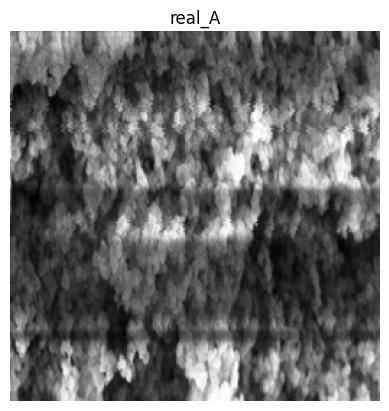

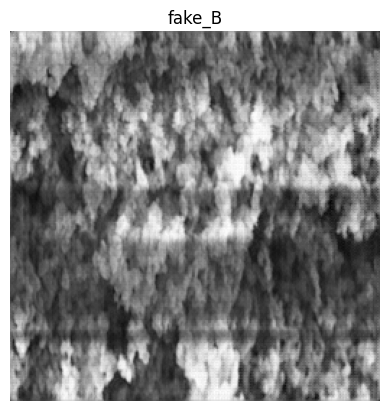

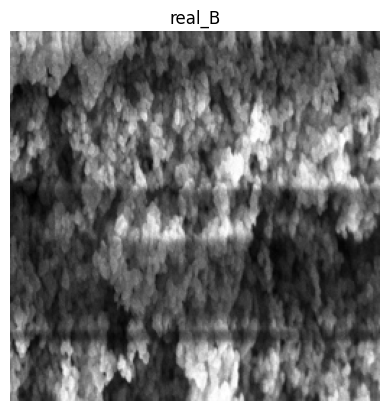

Batch 20: OrderedDict([('G_GAN', 3.0159342288970947), ('G_L1', 5.0559186935424805), ('D_real', 0.0009034321992658079), ('D_fake', 0.3480606973171234)])


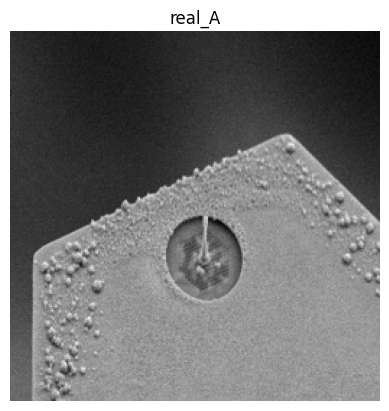

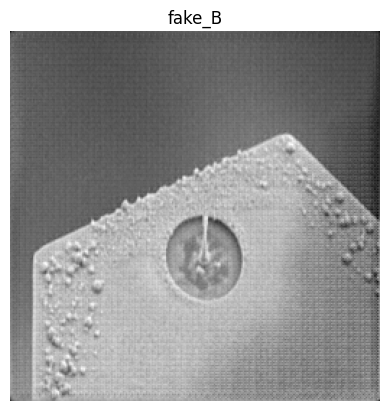

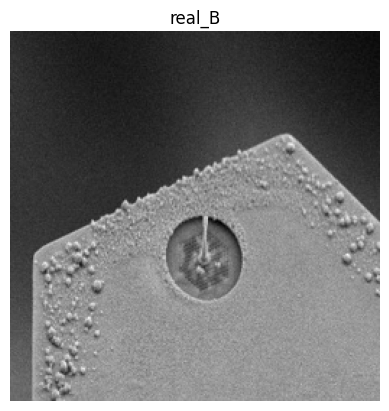

KeyboardInterrupt: 

In [52]:
p2p_model.eval()

val_loss_sum = 0.0
num_batches = 0

with torch.no_grad():
    for batch_idx, (x, y) in enumerate(val_loader):
        p2p_model.set_input({'A': x, 'B': y, 'A_paths': '', 'B_paths': ''})
        p2p_model.test()
        losses = p2p_model.get_current_losses()
        if batch_idx <= 20:
            if (batch_idx + 1) % 10 == 0:
                print(f"Batch {batch_idx + 1}: {p2p_model.get_current_losses()}")
                visuals = p2p_model.get_current_visuals()

                for name, img in visuals.items():
                    img = img.detach().cpu()
                    if img.ndim == 4:
                        img = img[0]
                    if img.shape[0] == 1:
                        img = img.squeeze(0)
                        plt.imshow(img.numpy(), cmap='gray')
                    else:
                        plt.imshow(img.permute(1, 2, 0).numpy())
                    plt.title(name)
                    plt.axis('off')
                    plt.show()
                


In [57]:
noise_obj = NoiseImage()

In [70]:
def noisy_sample(A):
    with Image.open(A) as img:
        img_array = np.array(img)[:, :, 0]

    noise_obj = NoiseImage()
    noisy_ip = noise_obj.augment((img_array * 255).astype(np.uint8)).astype(np.float32) / 255.0

    out = transform_3(256 , True)
    x = out(image = noisy_ip)["image"]
    y = out(image=img_array.astype(np.float32))["image"]

    x_noised = torch.from_numpy(x).unsqueeze(0).unsqueeze(0).float()
    y_batch = torch.from_numpy(y).unsqueeze(0).unsqueeze(0).float()
    x_noised = x_noised.repeat(1, 3, 1, 1)
    y_batch = y_batch.repeat(1, 3, 1, 1)

def predict_only_A(model, A, device):
    model.eval()
    with torch.no_grad():
        model.set_input({
            "A": A.unsqueeze(0).to(device),
            "B": A.unsqueeze(0).to(device),
            "A_paths": "",
            "B_paths": ""
        })
        model.test()
        return model.get_current_visuals()["fake_B"]
    

In [71]:
def tensor_to_display(img_t):
    img_t = img_t.detach().cpu()

    if img_t.dim() == 4:
        img_t = img_t[0]

    if img_t.shape[0] == 3:
        img_t = img_t[0]

    img_np = img_t.numpy()

    # If your transform used Normalize(mean=0.5, std=0.5), uncomment this:
    # img_np = (img_np * 0.5) + 0.5

    img_np = np.clip(img_np, 0, 1)
    return img_np

def run_single_image_inference(ip_img, model, transform, noise_obj, device):
    y_batch, x_noised = noisy_sample(ip_img)
    fake_B, real_A = predict_only_A(model, x_noised[0], device)

    gt_vis = tensor_to_display(y_batch)
    fake_vis = tensor_to_display(fake_B)
    realA_vis = tensor_to_display(real_A)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(gt_vis, cmap="gray")
    axes[0].set_title("Ground Truth")
    axes[0].axis("off")

    axes[1].imshow(fake_vis, cmap="gray")
    axes[1].set_title("Fake B")
    axes[1].axis("off")

    axes[2].imshow(realA_vis, cmap="gray")
    axes[2].set_title("Real A")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return {
        "ground_truth": y_batch,
        "real_A": real_A,
        "fake_B": fake_B,
        "x_noised": x_noised
    }

In [72]:
ip_img = '/Users/tjsss/Desktop/bharatAtomic/semPhase1/notebooks/images/Red-Velvet-Mite-SEM-Image.jpg'

out = run_single_image_inference(
    ip_img=ip_img,
    model=p2p_model,
    transform=transform_3,
    noise_obj=noise_obj,
    device=device
)

TypeError: cannot unpack non-iterable NoneType object